# Topic Modeling - Data Exploration

Khám phá dataset arXiv abstracts: phân phối nhãn, thống kê độ dài văn bản, và các đặc trưng của dữ liệu trước khi training.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

os.makedirs('./outputs/figures', exist_ok=True)
sys.path.append('..')
from src.dataset import load_raw_dataset, filter_sample, build_label_mappings, split_dataset
from src.preprocessing import preprocess_samples

/home/wotttoo/topic_modeling/topic_modeling_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Thiết lập

Import các thư viện và module cần thiết.

In [2]:
CACHE_DIR = '../cache'
CATEGORIES = ['astro-ph', 'cond-mat', 'cs', 'math', 'physics']
MAX_SAMPLES = 1000

## 2. Load Dataset

Load dataset `UniverseTBD/arxiv-abstracts-large` từ HuggingFace (2.29 triệu papers). Dataset gồm các trường: `id`, `abstract`, `categories`, `authors`, v.v.

In [3]:
# load data from HuggingFace
ds = load_raw_dataset(CACHE_DIR)
ds

DatasetDict({
    train: Dataset({
        features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed'],
        num_rows: 2292057
    })
})

In [4]:
# print three first examples
for i in range(3):
    print(f"Example {i+1}:")
    print(ds['train'][i]['abstract'])
    print(ds['train'][i]['categories'])
    print("---" * 20)

Example 1:
  A fully differential calculation in perturbative quantum chromodynamics is
presented for the production of massive photon pairs at hadron colliders. All
next-to-leading order perturbative contributions from quark-antiquark,
gluon-(anti)quark, and gluon-gluon subprocesses are included, as well as
all-orders resummation of initial-state gluon radiation valid at
next-to-next-to-leading logarithmic accuracy. The region of phase space is
specified in which the calculation is most reliable. Good agreement is
demonstrated with data from the Fermilab Tevatron, and predictions are made for
more detailed tests with CDF and DO data. Predictions are shown for
distributions of diphoton pairs produced at the energy of the Large Hadron
Collider (LHC). Distributions of the diphoton pairs from the decay of a Higgs
boson are contrasted with those produced from QCD processes at the LHC, showing
that enhanced sensitivity to the signal can be obtained with judicious
selection of events.

hep-p

## 3. Khám phá Dataset Thô

Phân tích phân phối category trong toàn bộ dataset gốc trước khi filter.

In [5]:
# Thống kê số lượng single-label vs multi-label
all_cats = ds['train']['categories'][:10000]
single = sum(1 for c in all_cats if len(c.split()) == 1)
multi = len(all_cats) - single
print(f"Trong 10,000 samples đầu:")
print(f"  Single-label: {single} ({single/len(all_cats)*100:.1f}%)")
print(f"  Multi-label:  {multi} ({multi/len(all_cats)*100:.1f}%)")

Trong 10,000 samples đầu:
  Single-label: 6389 (63.9%)
  Multi-label:  3611 (36.1%)


In [6]:
# filter 1000 samples
samples = filter_sample(ds, CATEGORIES, MAX_SAMPLES)
samples[0]

{'id': '0704.0003',
 'submitter': 'Hongjun Pan',
 'authors': 'Hongjun Pan',
 'title': 'The evolution of the Earth-Moon system based on the dark matter field\n  fluid model',
 'comments': '23 pages, 3 figures',
 'journal-ref': None,
 'doi': None,
 'report-no': None,
 'categories': 'physics.gen-ph',
 'license': None,
 'abstract': "  The evolution of Earth-Moon system is described by the dark matter field\nfluid model proposed in the Meeting of Division of Particle and Field 2004,\nAmerican Physical Society. The current behavior of the Earth-Moon system agrees\nwith this model very well and the general pattern of the evolution of the\nMoon-Earth system described by this model agrees with geological and fossil\nevidence. The closest distance of the Moon to Earth was about 259000 km at 4.5\nbillion years ago, which is far beyond the Roche's limit. The result suggests\nthat the tidal friction may not be the primary cause for the evolution of the\nEarth-Moon system. The average dark matter fi

## 4. Tiền xử lý

Filter lấy 1000 samples single-label thuộc 5 category: `astro-ph`, `cond-mat`, `cs`, `math`, `physics`. Sau đó làm sạch text: bỏ ký tự đặc biệt, số, khoảng trắng thừa và chuyển về chữ thường.

In [7]:
# preprocessing data
preprocessed_samples = preprocess_samples(samples)
preprocessed_samples[0]

{'text': 'the evolution of earthmoon system is described by the dark matter field fluid model proposed in the meeting of division of particle and field american physical society the current behavior of the earthmoon system agrees with this model very well and the general pattern of the evolution of the moonearth system described by this model agrees with geological and fossil evidence the closest distance of the moon to earth was about km at billion years ago which is far beyond the roches limit the result suggests that the tidal friction may not be the primary cause for the evolution of the earthmoon system the average dark matter field fluid constant derived from earthmoon system data is x sm this model predicts that the marss rotation is also slowing with the angular acceleration rate about x rad s',
 'label': 'physics'}

## 5. Phân phối nhãn

Kiểm tra số lượng sample mỗi category sau khi filter để đảm bảo dữ liệu cân bằng (balanced dataset).

Phân phối nhãn:
  astro-ph: 434 samples (43.4%)
  cond-mat: 232 samples (23.2%)
  cs: 22 samples (2.2%)
  math: 216 samples (21.6%)
  physics: 96 samples (9.6%)


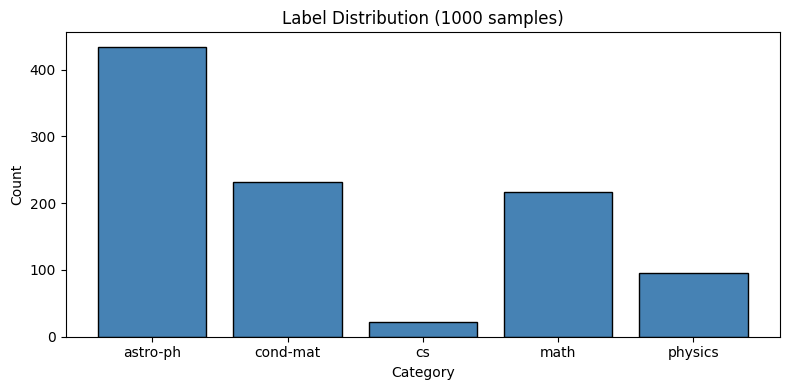

In [8]:
label_counts = Counter([s['label'] for s in preprocessed_samples])
labels = sorted(label_counts.keys())
counts = [label_counts[l] for l in labels]

print("Phân phối nhãn:")
for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count} samples ({count/len(preprocessed_samples)*100:.1f}%)")

plt.figure(figsize=(8, 4))
plt.bar(labels, counts, color='steelblue', edgecolor='black')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Label Distribution (1000 samples)')
plt.tight_layout()
plt.savefig('./outputs/figures/label_distribution.png')
plt.show()

In [9]:
# mapping
sorted_labels, label_to_id, id_to_label = build_label_mappings(preprocessed_samples)

## 6. Thống kê độ dài Abstract

Phân tích số lượng từ trong mỗi abstract sau khi tiền xử lý để hiểu độ dài trung bình và phân phối của văn bản.

Thống kê độ dài abstract (số từ):
  Min:    6
  Max:    297
  Mean:   133.5
  Median: 121.0
  Std:    67.9


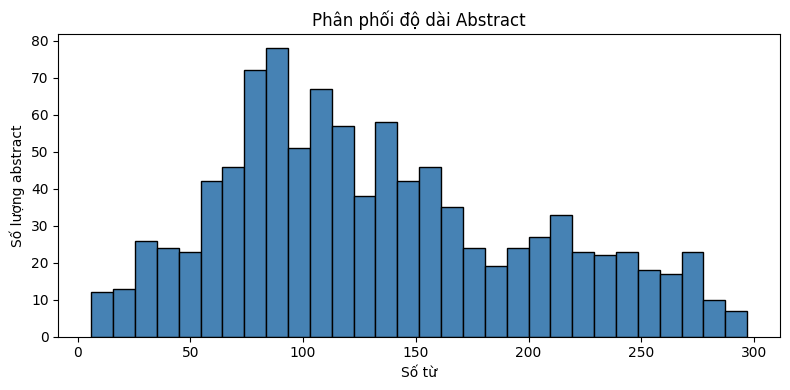

In [10]:
lengths = [len(s['text'].split()) for s in preprocessed_samples]

print("Thống kê độ dài abstract (số từ):")
print(f"  Min:    {min(lengths)}")
print(f"  Max:    {max(lengths)}")
print(f"  Mean:   {np.mean(lengths):.1f}")
print(f"  Median: {np.median(lengths):.1f}")
print(f"  Std:    {np.std(lengths):.1f}")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Số từ')
plt.ylabel('Số lượng abstract')
plt.title('Phân phối độ dài Abstract')
plt.tight_layout()
plt.savefig('./outputs/figures/abstract_length_distribution.png')
plt.show()

In [11]:
# Độ dài trung bình theo từng category
print("Độ dài trung bình theo category:")
for label in sorted(label_counts.keys()):
    cat_lengths = [len(s['text'].split()) for s in preprocessed_samples if s['label'] == label]
    print(f"  {label}: {np.mean(cat_lengths):.1f} từ")

Độ dài trung bình theo category:
  astro-ph: 174.8 từ
  cond-mat: 112.3 từ
  cs: 137.5 từ
  math: 84.0 từ
  physics: 108.7 từ


In [12]:
# split to train set and test set
X_train, X_test, y_train, y_test = split_dataset(preprocessed_samples, label_to_id, test_size=0.2, random_state=42)

In [13]:
sorted_labels, label_to_id, id_to_label = build_label_mappings(preprocessed_samples)
X_train, X_test, y_train, y_test = split_dataset(preprocessed_samples, label_to_id, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"\nPhân phối nhãn trong train set:")
for label, idx in label_to_id.items():
    count = y_train.count(idx)
    print(f"  {label}: {count} ({count/len(y_train)*100:.1f}%)")
print(f"\nPhân phối nhãn trong test set:")
for label, idx in label_to_id.items():
    count = y_test.count(idx)
    print(f"  {label}: {count} ({count/len(y_test)*100:.1f}%)")

Training samples: 800
Test samples:     200

Phân phối nhãn trong train set:
  astro-ph: 347 (43.4%)
  cond-mat: 186 (23.2%)
  cs: 17 (2.1%)
  math: 173 (21.6%)
  physics: 77 (9.6%)

Phân phối nhãn trong test set:
  astro-ph: 87 (43.5%)
  cond-mat: 46 (23.0%)
  cs: 5 (2.5%)
  math: 43 (21.5%)
  physics: 19 (9.5%)


## Tổng kết

- Dataset gồm 2.29 triệu papers, chọn ra **1000 samples** single-label thuộc 5 chủ đề chính.
- Dữ liệu **cân bằng** — mỗi category chiếm khoảng 200 samples (20%).
- Độ dài abstract trung bình khoảng **100-150 từ** sau khi tiền xử lý.
- Stratified split đảm bảo tỉ lệ nhãn giữ nguyên ở cả train (800) và test (200).

## 7. Train/Test Split

Chia dữ liệu thành tập train (80%) và test (20%) với `stratify=True` để đảm bảo tỉ lệ nhãn giống nhau ở cả 2 tập.